In [34]:
import numpy as np
import pandas as pd
import emcee
import matplotlib.pyplot as plt
import pycalphad.model as pype
from espei import pureElement as pe
from pycalphad.model import RWModelE,autoH,CSModelE,SRModelE,autoS,autoG, pe_dict, RTDB_globals, Define_Element
from espei.pureElement import imp_data_PE, log_probability, log_likelihood, Cp_fit, pe_inputJSON,pe_def_model, pe_iGuess
import json
import os
from typing import Dict, Any

In [35]:


def load_json_files(folder_path: str) -> Dict[str, Any]:
    results: Dict[str, Any] = {}

    if not os.path.exists(folder_path):
        raise FileNotFoundError(f"The directory {folder_path} does not exist.")

    json_files = [f for f in os.listdir(folder_path) if f.endswith('.json')]

    for json_file in json_files:
        key = json_file.split('_')[0]
        file_path = os.path.join(folder_path, json_file)
        try:
            with open(file_path, 'r') as file:
                results[key] = json.load(file)
        except json.JSONDecodeError:
            print(f"Error decoding JSON from {json_file}")
        except IOError:
            print(f"Error reading file {json_file}")

    return results

# Define the path to the Results folder
results_folder = 'c:/Users/xander/Documents/github_repositories/PureElement/41_Elements/FCC/Results'

# Load JSON files and store their contents in the results dictionary
try:
    results = load_json_files(results_folder)
    print(f"Successfully loaded {len(results)} JSON files.")
except FileNotFoundError as e:
    print(e)

# Now you can access the parameters using the results dictionary
# For example, if the filename is AG_OUTPUT.JSON, you can access it using results['AG']

Successfully loaded 11 JSON files.


In [36]:
elements=results.keys()
T_plot = np.linspace(0, 1500, 750)

## Solve

In [37]:
# Loop over each element and solve the models
for element in elements:
    element_data = results[element]
    Define_Element([element.upper()])
    
    # Solve RWModelE
    RWa = element_data['RW'][1]
    RWb = element_data['RW'][2]
    RWE = element_data['RW'][0]
    rw_model = RWModelE(T_plot, *np.array(element_data['RW']))
    
    # Solve CSModelE
    CSa = element_data['CS'][1]
    CSb = element_data['CS'][2]
    CSe = element_data['CS'][0]
    cs_model = CSModelE(T_plot, *np.array(element_data['CS']))
    
    # Solve SRModelE
    SRE = element_data['SR'][0]
    SR1 = element_data['SR'][1]
    SR2 = element_data['SR'][2]
    SR3 = element_data['SR'][3]
    SR4 = element_data['SR'][4]
    sr_model = SRModelE(T_plot, *np.array(element_data['SR']))
    
    # Solve G
    rwg_model = pype.GTRWM(T_plot, RWa, RWb)
    GRW1 = rwg_model + pype.GEin(RWE, T_plot)

    csg_model = pype.GTCSM(T_plot, CSa, CSb)
    GCS1 = csg_model + pype.GEin(CSe, T_plot)

    srg_model = pype.GTBCM(T_plot, SR1, SR2, SR3, SR4)
    GSR1 = srg_model + pype.GEin(SRE, T_plot)
    
    # Solve H
    HCS298=pype.HTCSM(298.15,CSa,CSb)+pype.HEin(CSe,298.15)#+pype.HM(T_range)[29]
    HSR298=pype.HTBCM(298.15,SR1, SR2, SR3, SR4)+pype.HEin(SRE,298.15)#+pype.HM(T_range)[149]
    HRW298=pype.HTRWM(298.15,RWa,RWb)+pype.HEin(RWE,298.15)
    HRW = pype.HTRWM(T_plot, RWa, RWb) + pype.HEin(RWE, T_plot) - HRW298
    HCS = pype.HTCSM(T_plot, CSa, CSb) + pype.HEin(CSe, T_plot) - HCS298
    HSR = pype.HTBCM(T_plot, SR1, SR2, SR3, SR4) + pype.HEin(SRE, T_plot) - HSR298

    # Solve S
    SRW = pype.STRWM(T_plot, RWa, RWb) + pype.SEin(RWE, T_plot)
    SCS = pype.STCSM(T_plot, CSa, CSb) + pype.SEin(CSe, T_plot)
    SSR = pype.STBCM(T_plot, SR1, SR2, SR3, SR4) + pype.SEin(SRE, T_plot)
    
    # Save results in unique variables
    exec(f"{element}_rw_model = rw_model")
    exec(f"{element}_cs_model = cs_model")
    exec(f"{element}_sr_model = sr_model")
    exec(f"{element}_GRW1 = GRW1")
    exec(f"{element}_GCS1 = GCS1")
    exec(f"{element}_GSR1 = GSR1")
    exec(f"{element}_HRW = HRW")
    exec(f"{element}_HCS = HCS")
    exec(f"{element}_HSR = HSR")
    exec(f"{element}_SRW = SRW")
    exec(f"{element}_SCS = SCS")
    exec(f"{element}_SSR = SSR")

-104.89374784544012 <class 'numpy.ndarray'> 750
0.0 <class 'numpy.ndarray'> 750


c:\Users\xander\anaconda3\envs\PESPEIv3\lib\site-packages\pycalphad\model.py:1638: RuntimeWarning: invalid value encountered in divide
  Cv_E = koef * (Te / T) ** 2 * np.exp(Te / T) / (np.exp(Te / T) - 1) ** 2
c:\Users\xander\anaconda3\envs\PESPEIv3\lib\site-packages\pycalphad\model.py:1695: RuntimeWarning: invalid value encountered in scalar divide
  f1 = np.exp(Theta_E/i)/(np.exp(Theta_E/i)-1)**2.0
c:\Users\xander\anaconda3\envs\PESPEIv3\lib\site-packages\pycalphad\model.py:1870: RuntimeWarning: invalid value encountered in multiply
  Ge = koef*(x*np.log(np.exp(Te/x)-1)-Te) - HEin(Te, 298.15)
c:\Users\xander\anaconda3\envs\PESPEIv3\lib\site-packages\pycalphad\model.py:1954: RuntimeWarning: invalid value encountered in log
  S = (alfa -g)**2.0*(3.0*k2/(8.0*g) - k2 *np.log(alfa-g)/(4*g))*x+(k1-k2*(alfa-g)/(2.0*g))*x**2+k2/(8.0*g)*x**3.0+k2/(4.0*g)*(alfa-g)**2.0*x*np.log(x)
c:\Users\xander\anaconda3\envs\PESPEIv3\lib\site-packages\pycalphad\model.py:1954: RuntimeWarning: invalid value e

-105.80683112830998 <class 'numpy.ndarray'> 750
0.0 <class 'numpy.ndarray'> 750
-114.19791555889552 <class 'numpy.ndarray'> 750
0.0 <class 'numpy.ndarray'> 750
-371.2418189200866 <class 'numpy.ndarray'> 750
0.0 <class 'numpy.ndarray'> 750
-676.7020905857952 <class 'numpy.ndarray'> 750
0.0 <class 'numpy.ndarray'> 750
-92.71040485174761 <class 'numpy.ndarray'> 750
0.0 <class 'numpy.ndarray'> 750


c:\Users\xander\anaconda3\envs\PESPEIv3\lib\site-packages\pycalphad\model.py:1956: RuntimeWarning: invalid value encountered in log
  S = (-3.0*k2*alfa/2 - k2/(4.0*g)*((alfa-g)**2 * np.log(alfa-g)-(alfa+g)**2*np.log(alfa+g)))*x+(k1+k2)*x**2-k2*alfa*x*np.log(x)
c:\Users\xander\anaconda3\envs\PESPEIv3\lib\site-packages\pycalphad\model.py:1938: RuntimeWarning: invalid value encountered in log
  Si = (-3.0*k2*alfa/2 - k2/(4.0*g)*((alfa-g)**2 * np.log(alfa-g)-(alfa+g)**2*np.log(alfa+g)))+(k1+k2)*i-k2*alfa*np.log(i)


-219.71482861359826 <class 'numpy.ndarray'> 750
0.0 <class 'numpy.ndarray'> 750
-199.98125098020634 <class 'numpy.ndarray'> 750
0.0 <class 'numpy.ndarray'> 750
-181.35671638953053 <class 'numpy.ndarray'> 750
0.0 <class 'numpy.ndarray'> 750
-190.05417348908978 <class 'numpy.ndarray'> 750
0.0 <class 'numpy.ndarray'> 750
-213.395630480164 <class 'numpy.ndarray'> 750
0.0 <class 'numpy.ndarray'> 750


In [38]:
elementsR = [element for element in elements if element != 'Cs']

## Gibbs

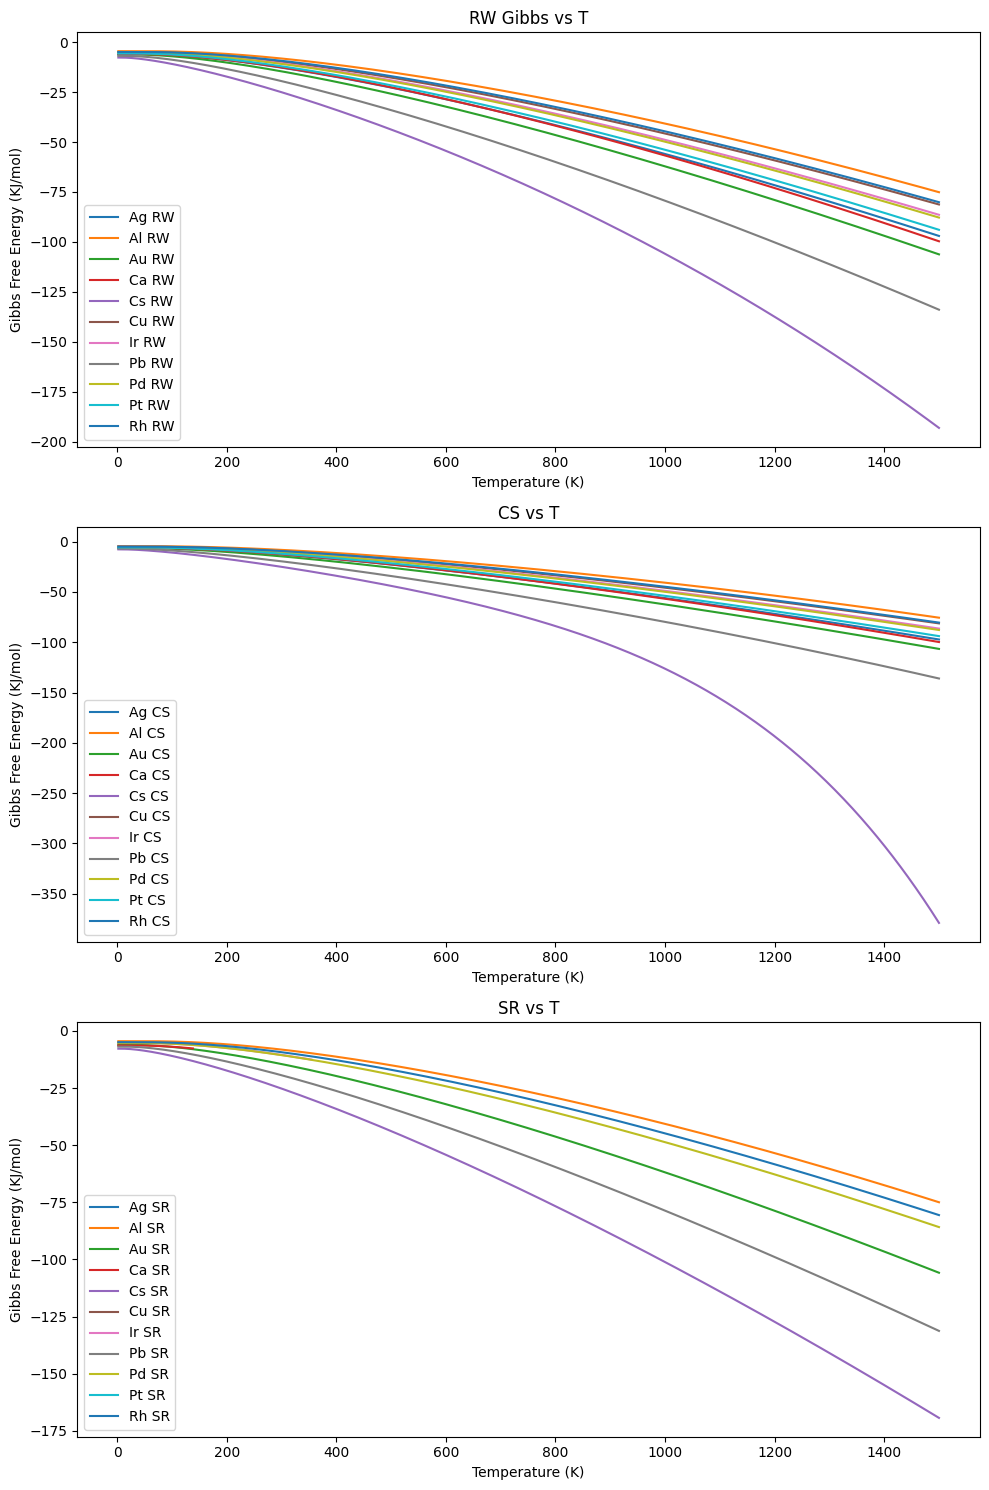

In [39]:
# Plot every similar variable result against T_plot
fig, axs = plt.subplots(3, 1, figsize=(10, 15))

for element in elements:
    axs[0].plot(T_plot, eval(f'{element}_GRW1')/1000, label=f'{element} RW')
    axs[1].plot(T_plot, eval(f'{element}_GCS1')/1000, label=f'{element} CS')
    axs[2].plot(T_plot, eval(f'{element}_GSR1')/1000, label=f'{element} SR')

axs[0].set_title('RW Gibbs vs T')
axs[1].set_title('CS vs T')
axs[2].set_title('SR vs T')

for ax in axs:
    ax.set_xlabel('Temperature (K)')
    ax.set_ylabel('Gibbs Free Energy (KJ/mol)')
    ax.legend()

plt.tight_layout()
plt.show()

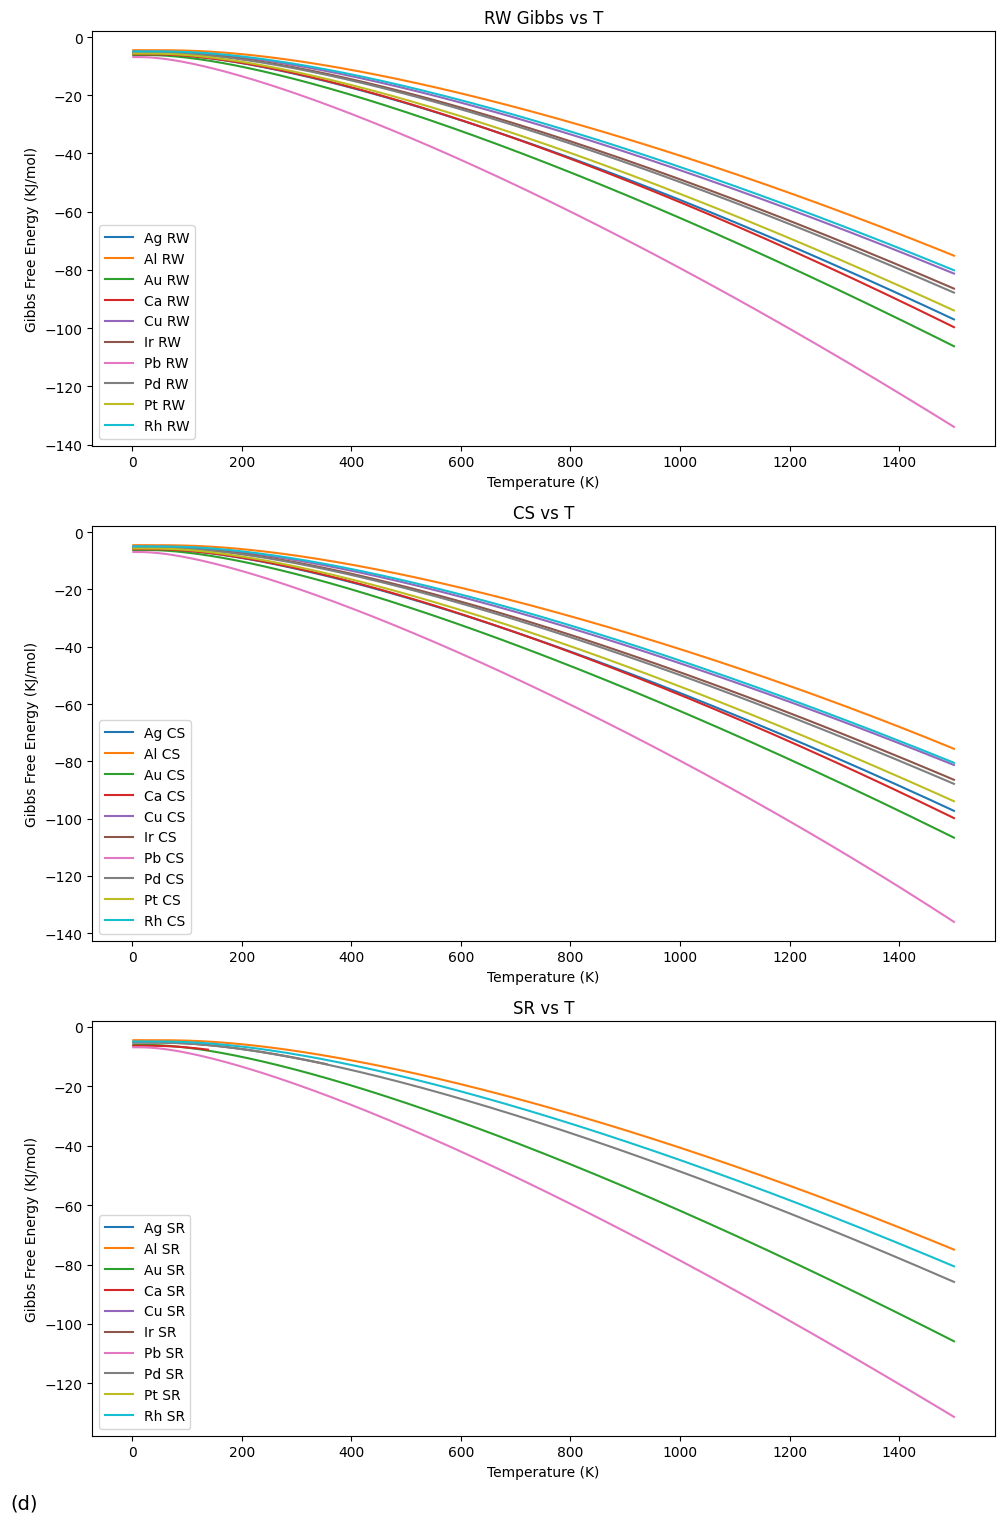

In [54]:
# Plot every similar variable result against T_plot
fig, axs = plt.subplots(3, 1, figsize=(10, 15))

for element in elementsR:
    axs[0].plot(T_plot, eval(f'{element}_GRW1')/1000, label=f'{element} RW')
    axs[1].plot(T_plot, eval(f'{element}_GCS1')/1000, label=f'{element} CS')
    axs[2].plot(T_plot, eval(f'{element}_GSR1')/1000, label=f'{element} SR')

axs[0].set_title('RW Gibbs vs T')
axs[1].set_title('CS vs T')
axs[2].set_title('SR vs T')

for ax in axs:
    ax.set_xlabel('Temperature (K)')
    ax.set_ylabel('Gibbs Free Energy (KJ/mol)')
    ax.legend()
plt.gcf().text(0.0, 0.0, '(d)', verticalalignment='top', horizontalalignment='left', fontsize=14)
plt.tight_layout()
plt.show()

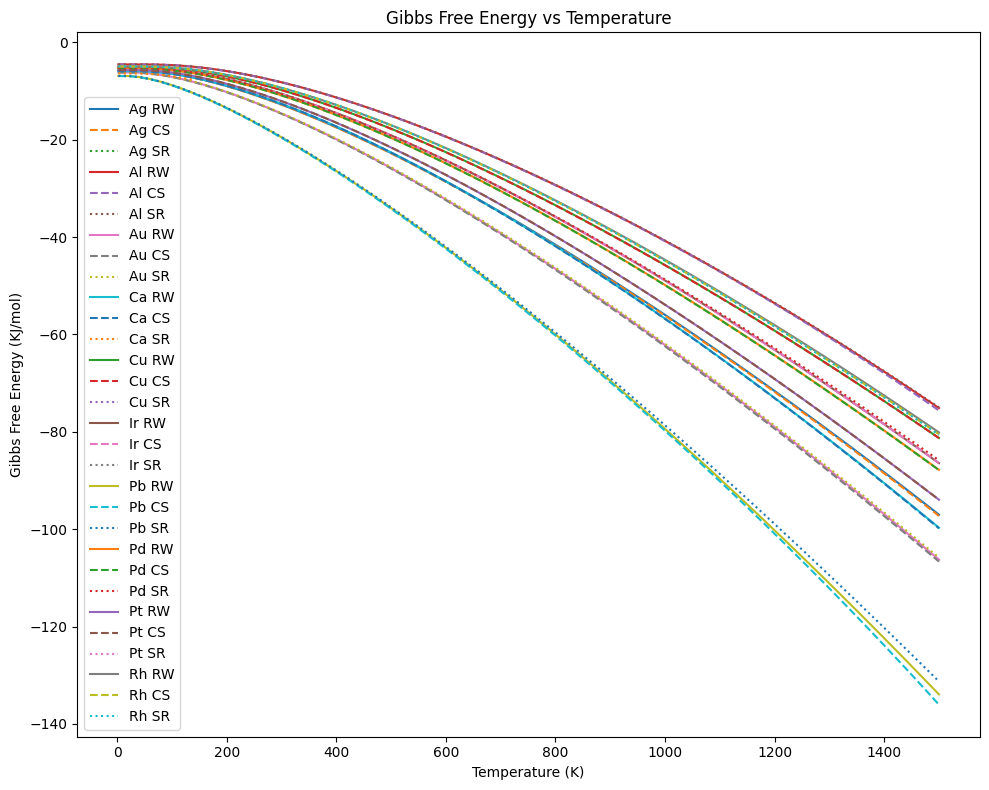

In [41]:
# Plot combined results against T_plot
fig, ax = plt.subplots(figsize=(10, 8))

for element in elementsR:
    ax.plot(T_plot, eval(f'{element}_GRW1')/1000, label=f'{element} RW', linestyle='-')
    ax.plot(T_plot, eval(f'{element}_GCS1')/1000, label=f'{element} CS', linestyle='--')
    ax.plot(T_plot, eval(f'{element}_GSR1')/1000, label=f'{element} SR', linestyle=':')

ax.set_title('Gibbs Free Energy vs Temperature')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Gibbs Free Energy (KJ/mol)')
ax.legend()

plt.tight_layout()
plt.show()


## Heat Capacity

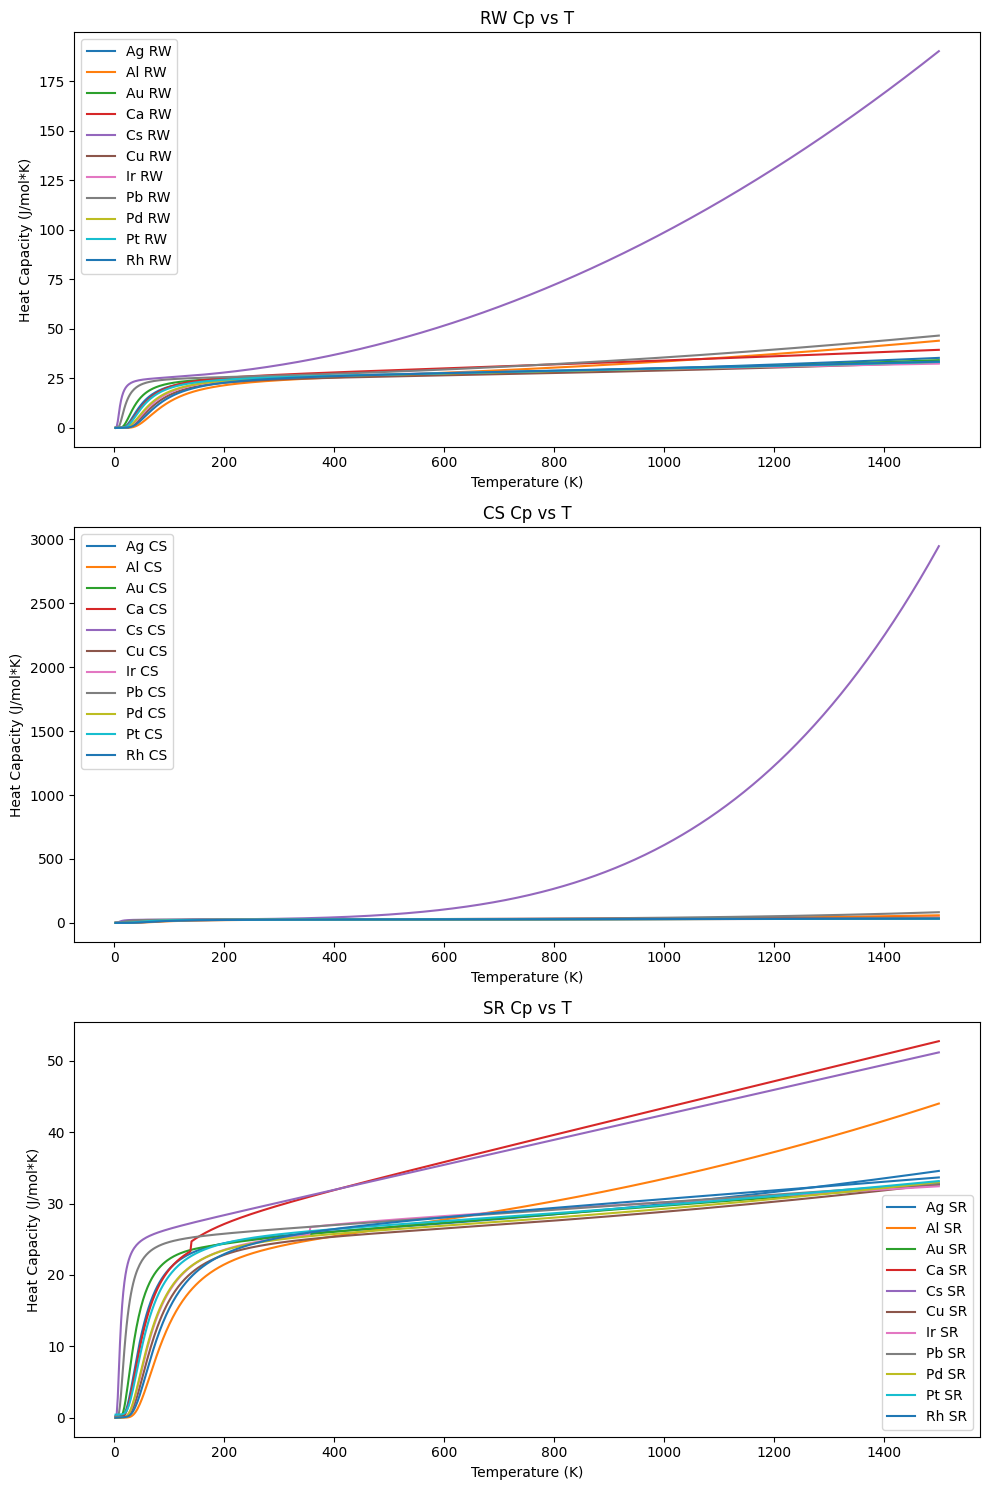

In [42]:
# Plot every similar variable result against T_plot
fig, axs = plt.subplots(3, 1, figsize=(10, 15))

for element in elements:
    axs[0].plot(T_plot, eval(f'{element}_rw_model'), label=f'{element} RW')
    axs[1].plot(T_plot, eval(f'{element}_cs_model'), label=f'{element} CS')
    axs[2].plot(T_plot, eval(f'{element}_sr_model'), label=f'{element} SR')

axs[0].set_title('RW Cp vs T')
axs[1].set_title('CS Cp vs T')
axs[2].set_title('SR Cp vs T')

for ax in axs:
    ax.set_xlabel('Temperature (K)')
    ax.set_ylabel('Heat Capacity (J/mol*K)')
    ax.legend()

plt.tight_layout()
plt.show()

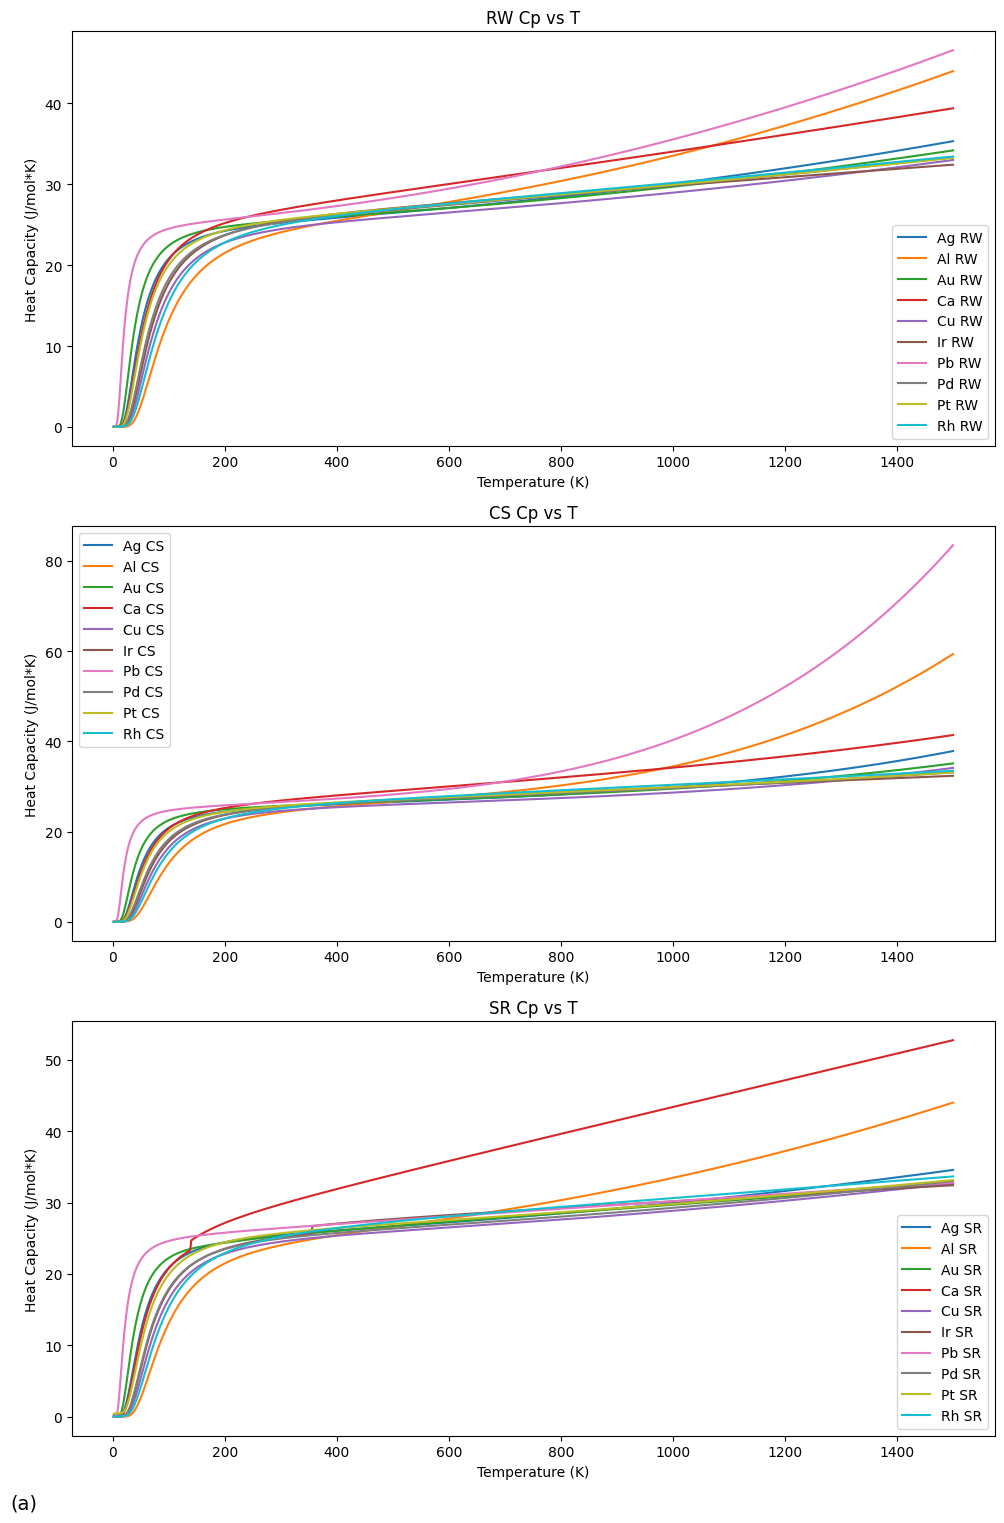

In [55]:
# Plot every similar variable result against T_plot
fig, axs = plt.subplots(3, 1, figsize=(10, 15))

for element in elementsR:
    axs[0].plot(T_plot, eval(f'{element}_rw_model'), label=f'{element} RW')
    axs[1].plot(T_plot, eval(f'{element}_cs_model'), label=f'{element} CS')
    axs[2].plot(T_plot, eval(f'{element}_sr_model'), label=f'{element} SR')

axs[0].set_title('RW Cp vs T')
axs[1].set_title('CS Cp vs T')
axs[2].set_title('SR Cp vs T')

for ax in axs:
    ax.set_xlabel('Temperature (K)')
    ax.set_ylabel('Heat Capacity (J/mol*K)')
    ax.legend()
plt.gcf().text(0.0, 0.0, '(a)', verticalalignment='top', horizontalalignment='left', fontsize=14)
plt.tight_layout()
plt.show()

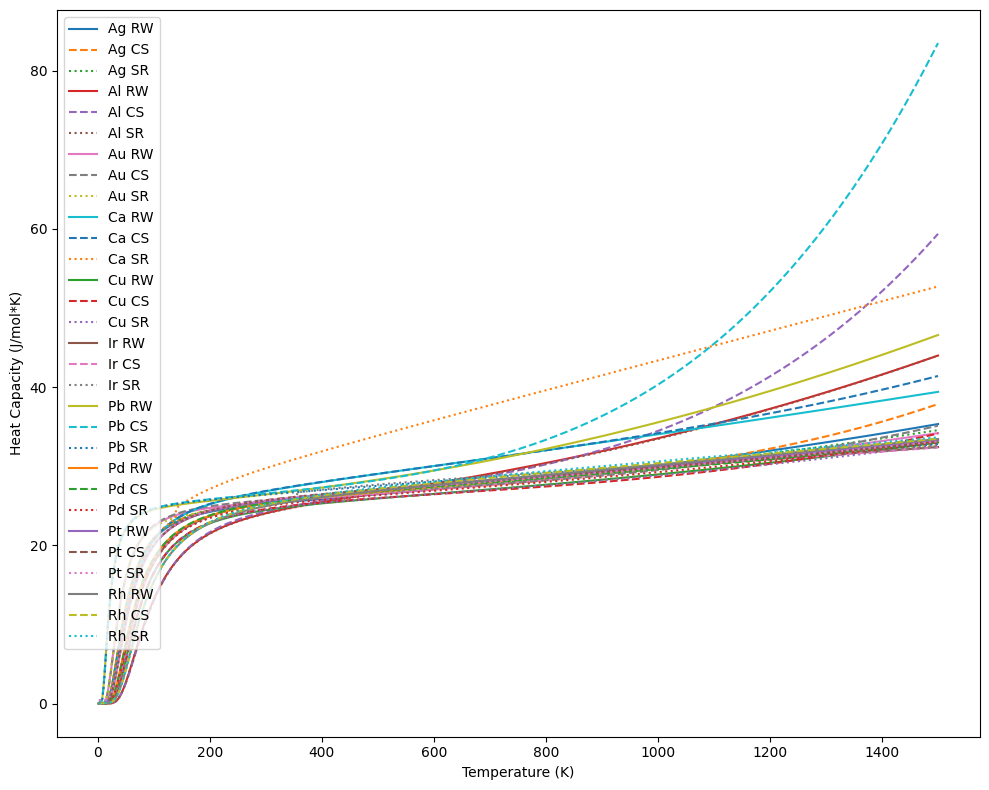

In [44]:
# Plot combined results against T_plot
fig, ax = plt.subplots(figsize=(10, 8))

for element in elementsR:
    ax.plot(T_plot, eval(f'{element}_rw_model'), label=f'{element} RW', linestyle='-')
    ax.plot(T_plot, eval(f'{element}_cs_model'), label=f'{element} CS', linestyle='--')
    ax.plot(T_plot, eval(f'{element}_sr_model'), label=f'{element} SR', linestyle=':')

#ax.set_title('Gibbs Free Energy vs Temperature')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Heat Capacity (J/mol*K)')
ax.legend()

plt.tight_layout()
plt.show()


## Enthalpy

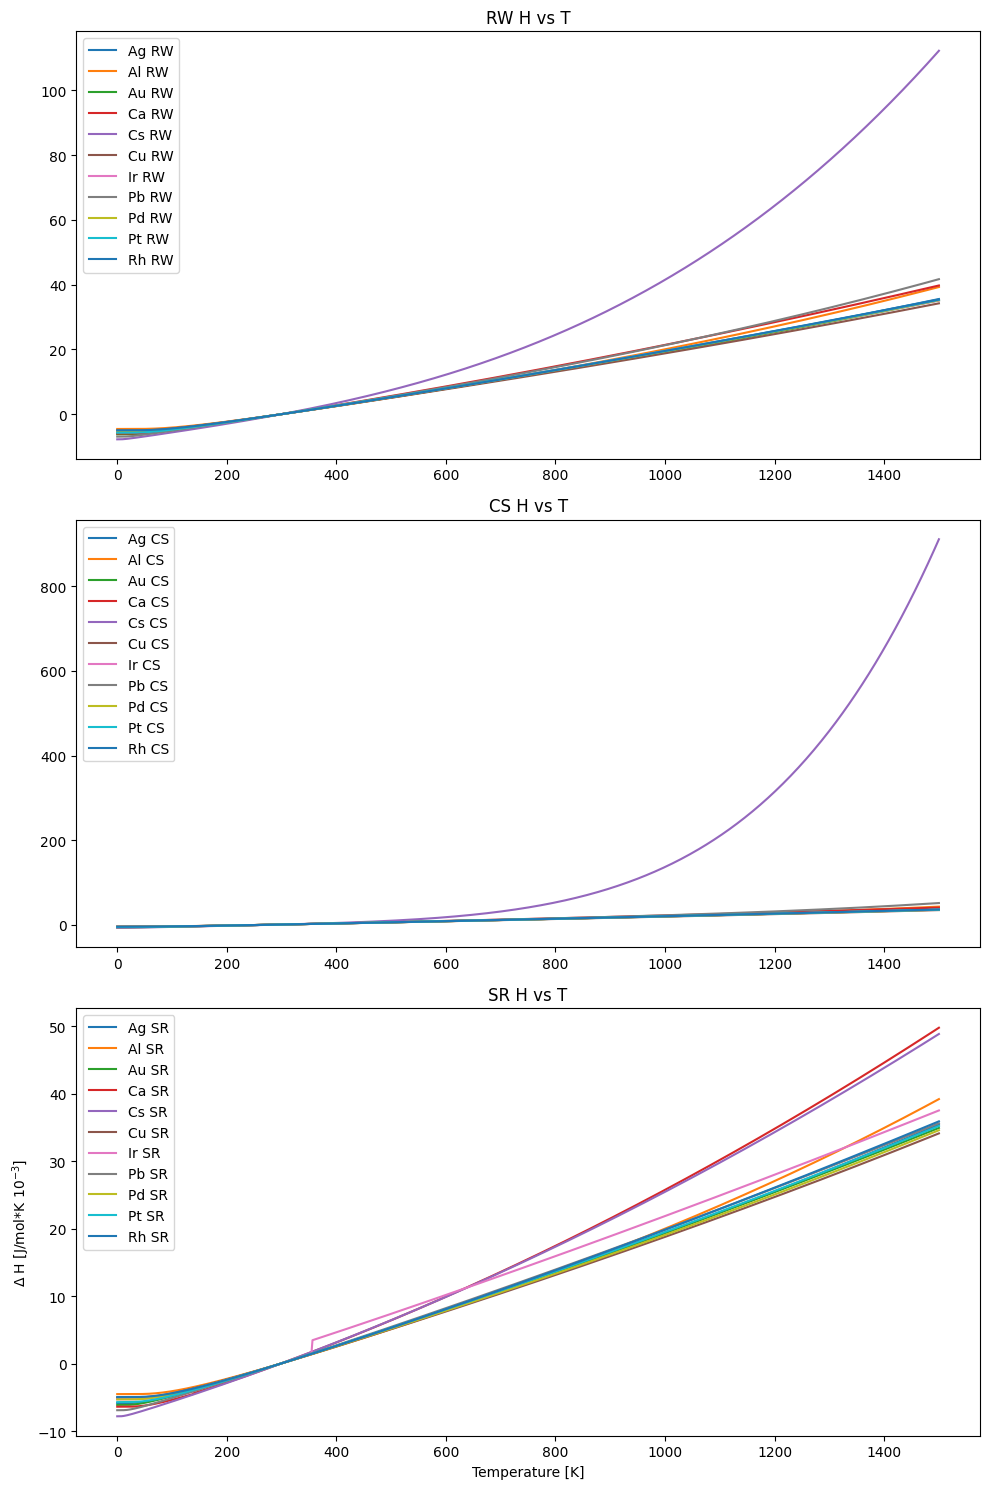

In [45]:
# Plot every similar variable result against T_plot
fig, axs = plt.subplots(3, 1, figsize=(10, 15))

for element in elements:
    axs[0].plot(T_plot, 10**-3*eval(f'{element}_HRW'), label=f'{element} RW')
    axs[1].plot(T_plot, 10**-3*eval(f'{element}_HCS'), label=f'{element} CS')
    axs[2].plot(T_plot, 10**-3*eval(f'{element}_HSR'), label=f'{element} SR')

axs[0].set_title('RW H vs T')
axs[1].set_title('CS H vs T')
axs[2].set_title('SR H vs T')

for ax in axs:
    plt.xlabel("Temperature [K]")
    plt.ylabel(r'$\Delta$ H [J/mol*K $10^{-3}$]')
    ax.legend()

plt.tight_layout()
plt.show()

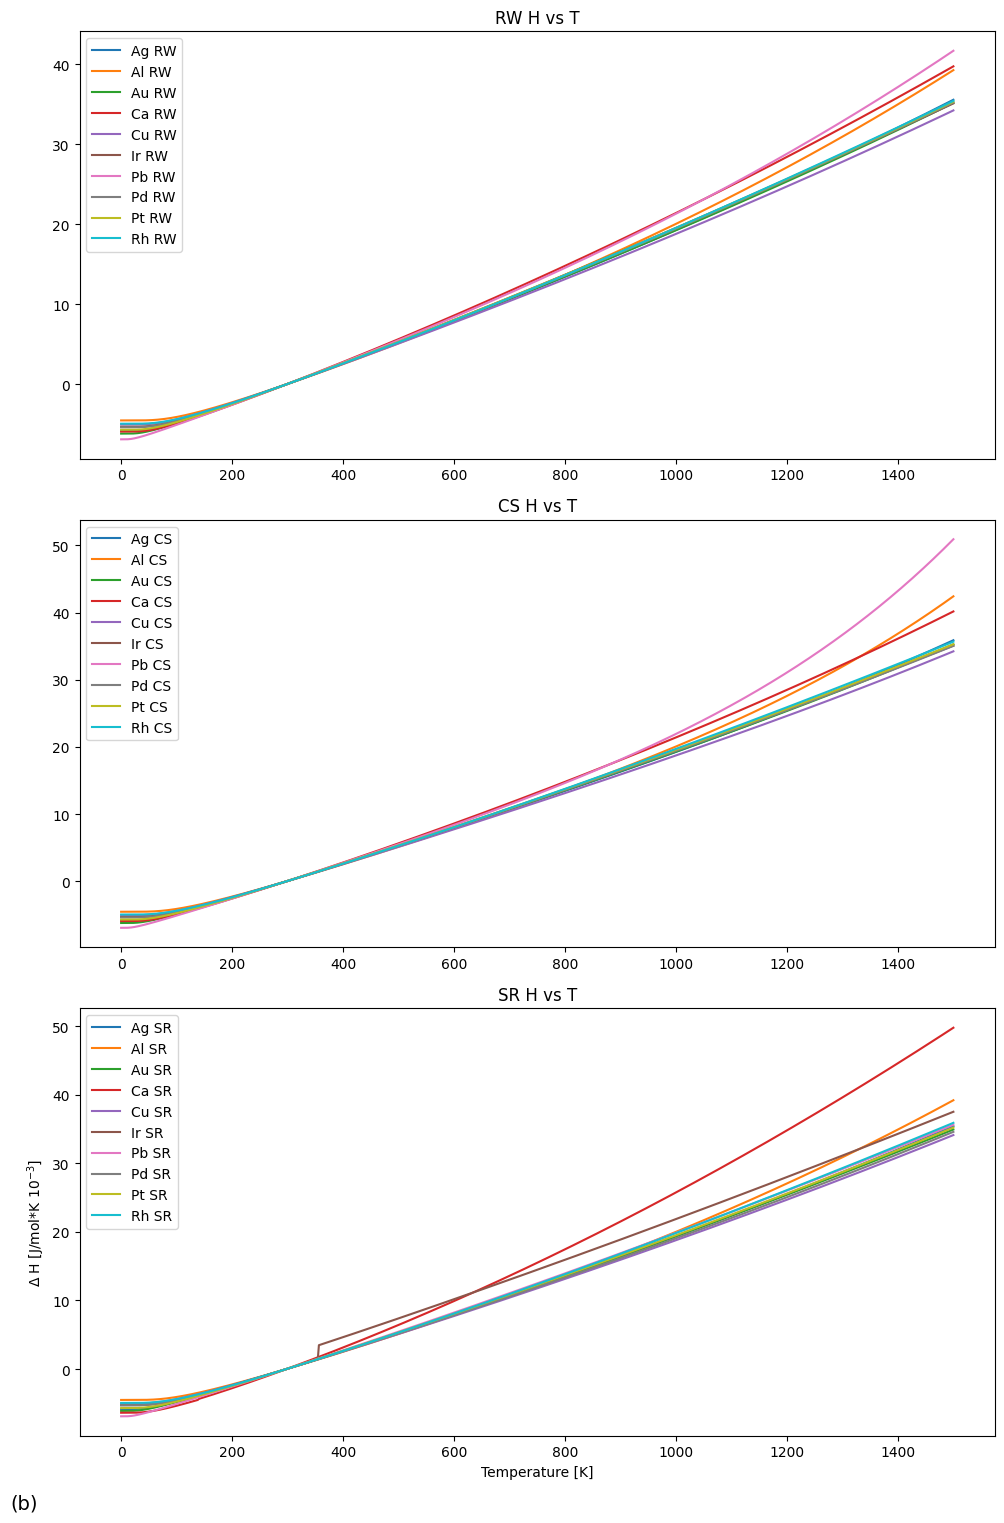

In [56]:
# Plot every similar variable result against T_plot
fig, axs = plt.subplots(3, 1, figsize=(10, 15))

for element in elementsR:
    axs[0].plot(T_plot, 10**-3*eval(f'{element}_HRW'), label=f'{element} RW')
    axs[1].plot(T_plot, 10**-3*eval(f'{element}_HCS'), label=f'{element} CS')
    axs[2].plot(T_plot, 10**-3*eval(f'{element}_HSR'), label=f'{element} SR')

axs[0].set_title('RW H vs T')
axs[1].set_title('CS H vs T')
axs[2].set_title('SR H vs T')

for ax in axs:
    plt.xlabel("Temperature [K]")
    plt.ylabel(r'$\Delta$ H [J/mol*K $10^{-3}$]')
    ax.legend()
plt.gcf().text(0.0, 0.0, '(b)', verticalalignment='top', horizontalalignment='left', fontsize=14)
plt.tight_layout()
plt.show()

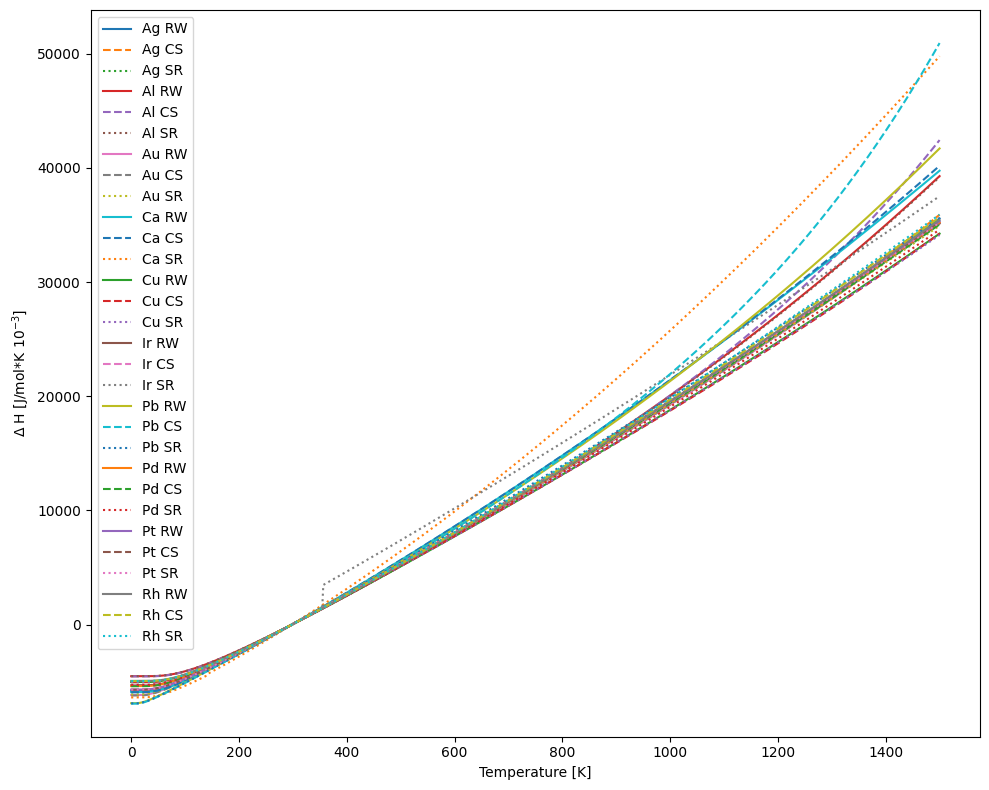

In [47]:
# Plot combined results against T_plot
fig, ax = plt.subplots(figsize=(10, 8))

for element in elementsR:
    ax.plot(T_plot, eval(f'{element}_HRW'), label=f'{element} RW', linestyle='-')
    ax.plot(T_plot, eval(f'{element}_HCS'), label=f'{element} CS', linestyle='--')
    ax.plot(T_plot, eval(f'{element}_HSR'), label=f'{element} SR', linestyle=':')

#ax.set_title('Gibbs Free Energy vs Temperature')
plt.xlabel("Temperature [K]")
plt.ylabel(r'$\Delta$ H [J/mol*K $10^{-3}$]')
ax.legend()

plt.tight_layout()
plt.show()


## Entropy

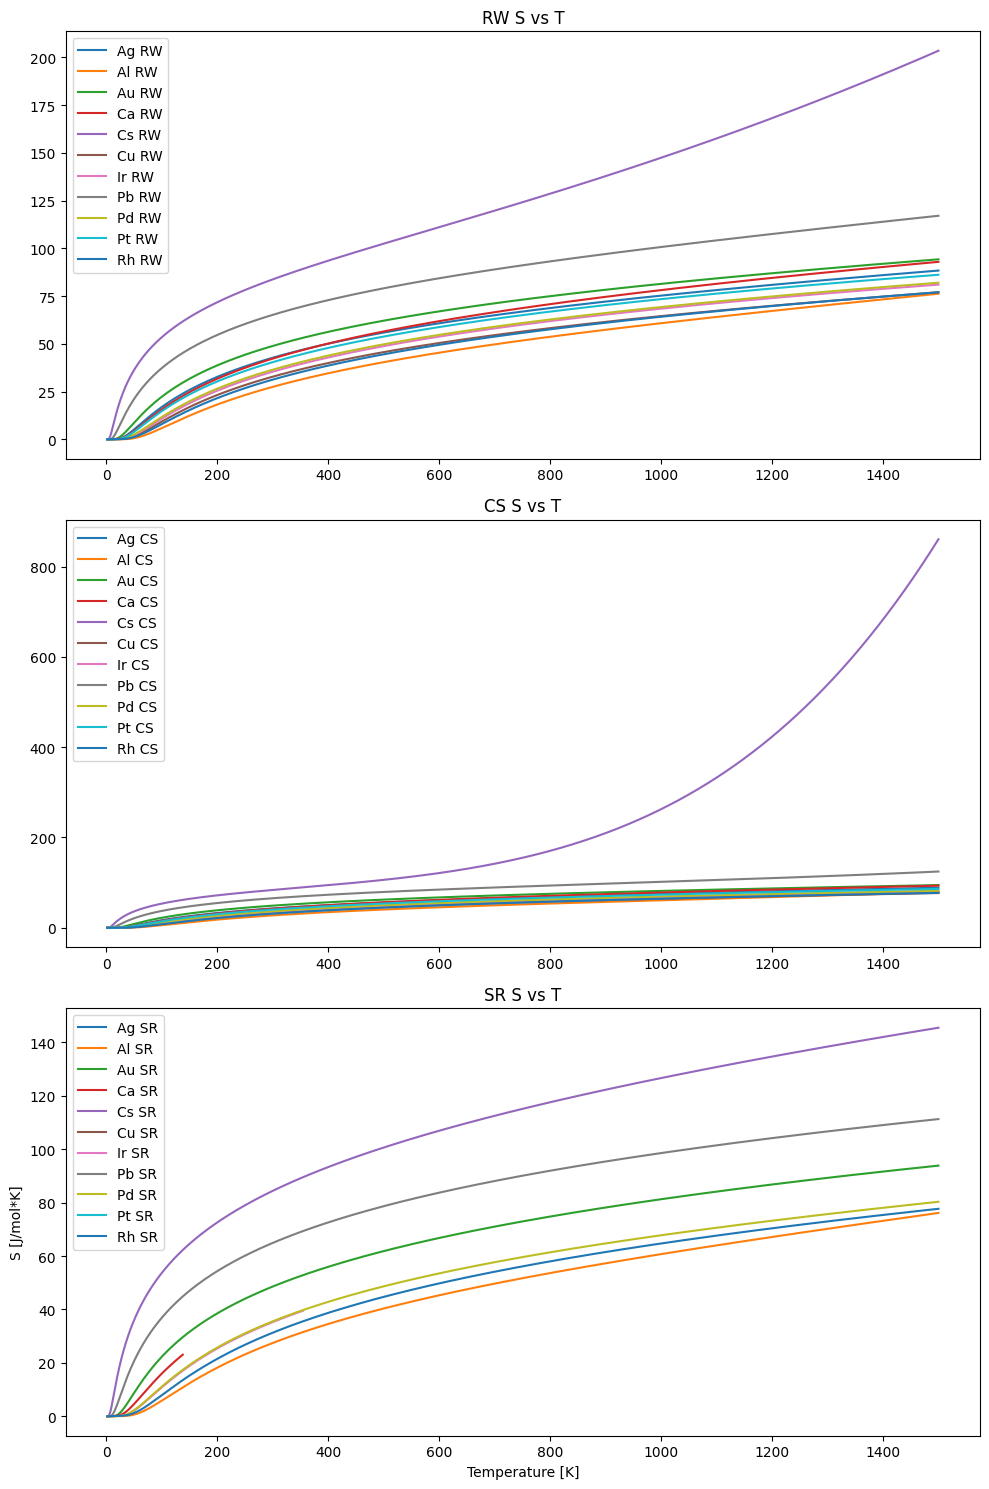

In [48]:
# Plot every similar variable result against T_plot
fig, axs = plt.subplots(3, 1, figsize=(10, 15))

for element in elements:
    axs[0].plot(T_plot, eval(f'{element}_SRW'), label=f'{element} RW')
    axs[1].plot(T_plot, eval(f'{element}_SCS'), label=f'{element} CS')
    axs[2].plot(T_plot, eval(f'{element}_SSR'), label=f'{element} SR')

axs[0].set_title('RW S vs T')
axs[1].set_title('CS S vs T')
axs[2].set_title('SR S vs T')

for ax in axs:
    plt.xlabel("Temperature [K]")
    plt.ylabel("S [J/mol*K]")
    ax.legend()

plt.tight_layout()
plt.show()

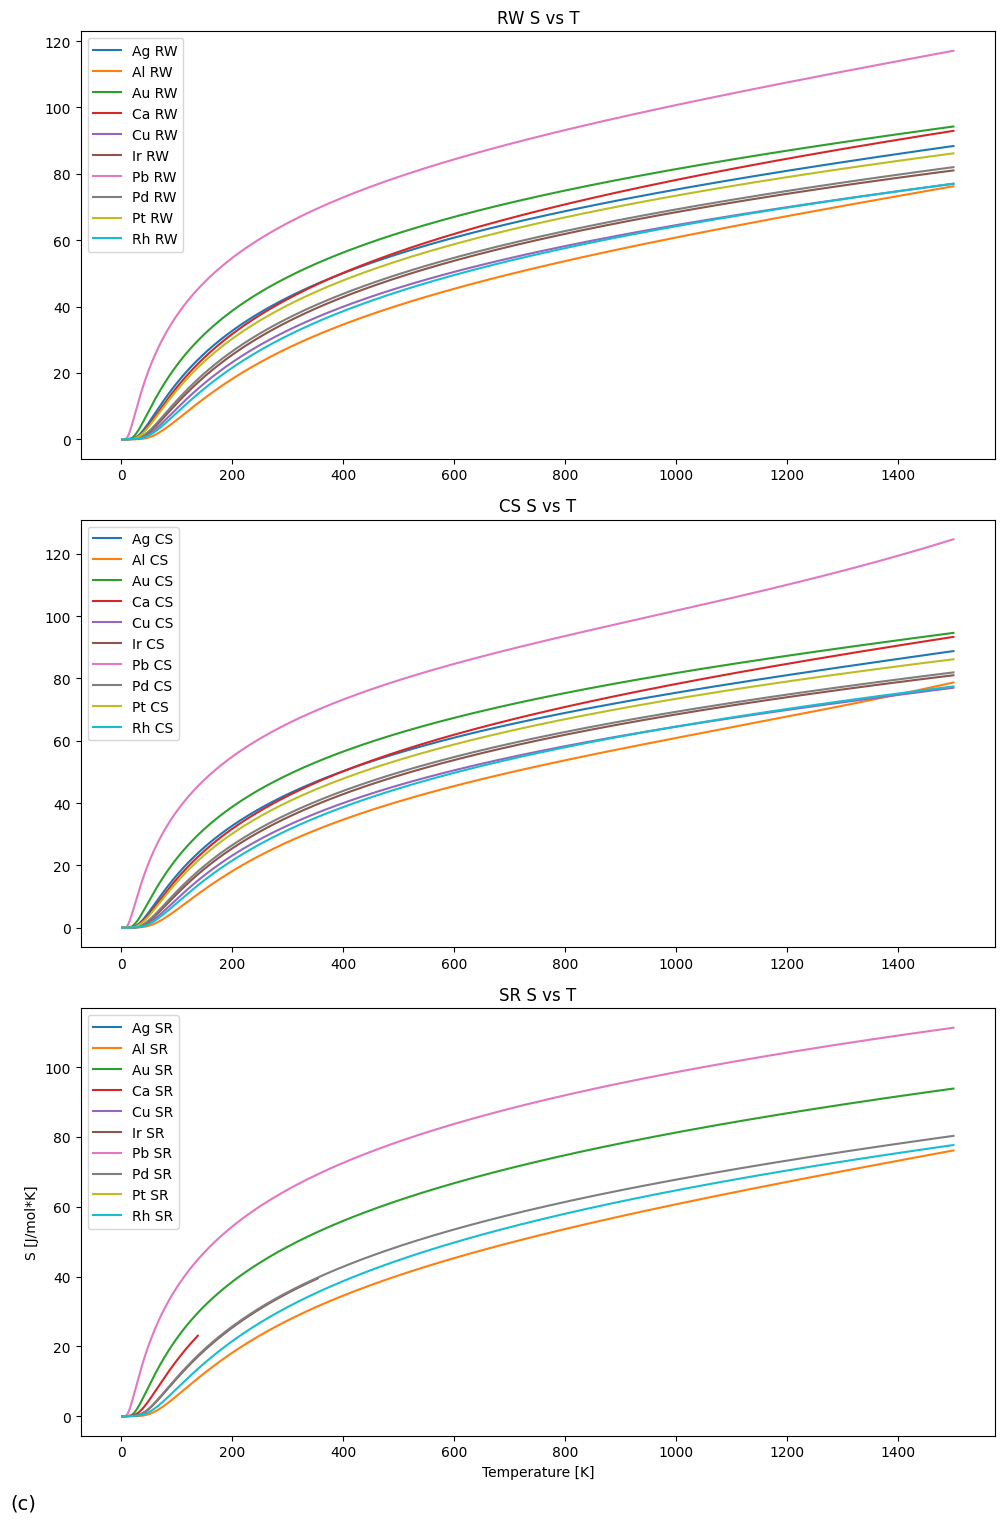

In [57]:
# Plot every similar variable result against T_plot
fig, axs = plt.subplots(3, 1, figsize=(10, 15))

for element in elementsR:
    axs[0].plot(T_plot, eval(f'{element}_SRW'), label=f'{element} RW')
    axs[1].plot(T_plot, eval(f'{element}_SCS'), label=f'{element} CS')
    axs[2].plot(T_plot, eval(f'{element}_SSR'), label=f'{element} SR')

axs[0].set_title('RW S vs T')
axs[1].set_title('CS S vs T')
axs[2].set_title('SR S vs T')

for ax in axs:
    plt.xlabel("Temperature [K]")
    plt.ylabel("S [J/mol*K]")
    ax.legend()
plt.gcf().text(0.0, 0.0, '(c)', verticalalignment='top', horizontalalignment='left', fontsize=14)
plt.tight_layout()
plt.show()

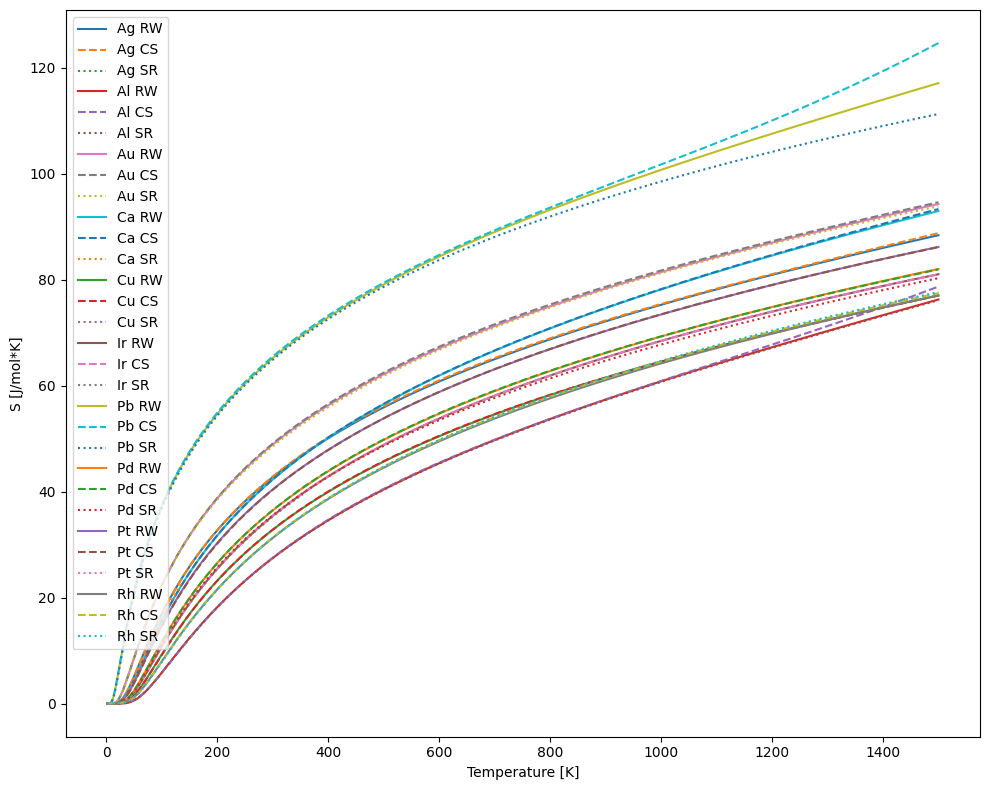

In [50]:
# Plot combined results against T_plot
fig, ax = plt.subplots(figsize=(10, 8))

for element in elementsR:
    ax.plot(T_plot, eval(f'{element}_SRW'), label=f'{element} RW', linestyle='-')
    ax.plot(T_plot, eval(f'{element}_SCS'), label=f'{element} CS', linestyle='--')
    ax.plot(T_plot, eval(f'{element}_SSR'), label=f'{element} SR', linestyle=':')

#ax.set_title('Gibbs Free Energy vs Temperature')
plt.xlabel("Temperature [K]")
plt.ylabel("S [J/mol*K]")
ax.legend()

plt.tight_layout()
plt.show()
